<a href="https://colab.research.google.com/github/Shreya-kudale-19/ml_basics-/blob/main/ML_using_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from urllib.request import urlretrieve

In [ ]:
italy_covid_url = 'https://gist.githubusercontent.com/aakashns/f6a004fa20c84fec53262f9a8bfee775/raw/f309558b1cf5103424cef58e2ecb8704dcd4d74c/italy-covid-daywise.csv'

urlretrieve(italy_covid_url, 'italy-covid-daywise.csv') #trying to retrive the csv file attachted to the url

('italy-covid-daywise.csv', <http.client.HTTPMessage at 0x78f830439ee0>)

In [ ]:
df = pd.read_csv('italy-covid-daywise.csv')

In [ ]:
df

,date,new_cases,new_deaths,new_tests
0,2019-12-31,0.0,0.0,NaN
1,2020-01-01,0.0,0.0,NaN
2,2020-01-02,0.0,0.0,NaN
3,2020-01-03,0.0,0.0,NaN
4,2020-01-04,0.0,0.0,NaN
...,...,...,...,...
243,2020-08-30,1444.0,1.0,53541.0
244,2020-08-31,1365.0,4.0,42583.0
245,2020-09-01,996.0,6.0,54395.0
246,2020-09-02,975.0,8.0,NaN


In [ ]:
df.describe()

,new_cases,new_deaths,new_tests
count,248.000000,248.000000,135.000000
mean,1094.818548,143.133065,31699.674074
std,1554.508002,227.105538,11622.209757
min,-148.000000,-31.000000,7841.000000
25%,123.000000,3.000000,25259.000000
50%,342.000000,17.000000,29545.000000
75%,1371.750000,175.250000,37711.000000
max,6557.000000,971.000000,95273.000000


In [ ]:
df.columns

Index(['date', 'new_cases', 'new_deaths', 'new_tests'], dtype='object')

In [ ]:
df['new_tests']

,new_tests
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
243,53541.0
244,42583.0
245,54395.0
246,NaN


this is a representation of how data is stored in the momery

In [ ]:
covid_data_dict ={
    'date' : ['2020-08-30','2020-08-31','2020-09-01','2020-09-02','2020-09-03'],
    'new_cases' :[1444.0, 1365.0, 996.0, 975.0, 1326.0],
    'new_deaths' :[1,4,6,8,6],
    'new_tests': [53541.0,42583.0,54395.0,None,None]
}

In [ ]:
res =covid_data_dict['new_cases']
type(res)

list

In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
df['new_cases'][246]

np.float64(975.0)

In [ ]:
df['new_tests'][243]

np.float64(53541.0)

In [ ]:
# retriving only 2 columns from the dataset
print( df[['date','new_cases']])

           date  new_cases
0    2019-12-31        0.0
1    2020-01-01        0.0
2    2020-01-02        0.0
3    2020-01-03        0.0
4    2020-01-04        0.0
..          ...        ...
243  2020-08-30     1444.0
244  2020-08-31     1365.0
245  2020-09-01      996.0
246  2020-09-02      975.0
247  2020-09-03     1326.0

[248 rows x 2 columns]


In [ ]:
df_copy = df.copy()  # shallow copy -> modification in one ds will not efect the other

In [ ]:
#  toacces a specific row at a specifc locatio we use-> .loc

df.loc[243]

,243
date,2020-08-30
new_cases,1444.0
new_deaths,1.0
new_tests,53541.0


In [ ]:
df.at[243,'new_cases']

np.float64(1444.0)

In [ ]:
total_new_cases = df.new_cases.sum()
total_new_cases

np.float64(271515.0)

In [ ]:
total_deaths = df.new_deaths.sum()
total_deaths

np.float64(35497.0)

In [ ]:
death_rate = total_deaths/total_new_cases * 100
print(f"{death_rate:.2f}")

13.07


In [ ]:
# to find the num of deaths in july
july = df[(df.date >= '2020-07-01') & (df.date <= '2020-07-31')]
july

,date,new_cases,new_deaths,new_tests
183,2020-07-01,142.0,23.0,29325.0
184,2020-07-02,182.0,21.0,29147.0
185,2020-07-03,201.0,30.0,25680.0
186,2020-07-04,223.0,15.0,28946.0
187,2020-07-05,235.0,21.0,21166.0
188,2020-07-06,192.0,7.0,13771.0
189,2020-07-07,208.0,8.0,22490.0
190,2020-07-08,137.0,30.0,28679.0
191,2020-07-09,193.0,15.0,29947.0
192,2020-07-10,214.0,12.0,27251.0


In [ ]:
july.sum()

,0
date,2020-07-012020-07-022020-07-032020-07-042020-0...
new_cases,6722.0
new_deaths,388.0
new_tests,797692.0


In [ ]:
# day with max cases
max_cases = max(df.new_cases)
max_cases

6557.0

In [ ]:
# 10 days with highest num of cases
Ten_highest_cases = df.sort_values('new_cases',ascending = False).head(10)
Ten_highest_cases



,date,new_cases,new_deaths,new_tests
82,2020-03-22,6557.0,795.0,NaN
87,2020-03-27,6153.0,660.0,NaN
81,2020-03-21,5986.0,625.0,NaN
89,2020-03-29,5974.0,887.0,NaN
88,2020-03-28,5959.0,971.0,NaN
83,2020-03-23,5560.0,649.0,NaN
80,2020-03-20,5322.0,429.0,NaN
85,2020-03-25,5249.0,743.0,NaN
90,2020-03-30,5217.0,758.0,NaN
86,2020-03-26,5210.0,685.0,NaN


In [ ]:
Ten_lowest_cases = df.sort_values('new_cases',ascending = True).head(10)
Ten_lowest_cases

,date,new_cases,new_deaths,new_tests
172,2020-06-20,-148.0,47.0,29875.0
0,2019-12-31,0.0,0.0,NaN
2,2020-01-02,0.0,0.0,NaN
1,2020-01-01,0.0,0.0,NaN
4,2020-01-04,0.0,0.0,NaN
5,2020-01-05,0.0,0.0,NaN
6,2020-01-06,0.0,0.0,NaN
3,2020-01-03,0.0,0.0,NaN
8,2020-01-08,0.0,0.0,NaN
9,2020-01-09,0.0,0.0,NaN


# ***data cleaning***

**Note** - Now here we have a negative value in new_case column which can be due go data entry error
this can be solved using:      
1.replace it with 0           
2.replace with average of entire column        
3.replace with avg of values on previous and next date            
4. discard the row entirely

In [ ]:
# avg of new_cases
total_avg = df.new_cases.mean()
total_avg

np.float64(1094.8185483870968)

In [ ]:
# avg of previous and next dates
negative_new_cases = df[df.new_cases < 0]
negative_new_cases

print(df.loc[171:173])

           date  new_cases  new_deaths  new_tests
171  2020-06-19      331.0        66.0    28570.0
172  2020-06-20     -148.0        47.0    29875.0
173  2020-06-21      264.0        49.0    24581.0


In [ ]:
recent_avg = df.loc[171:173].new_cases.mean()-df.loc[172].new_cases
recent_avg

np.float64(297.0)

here we are replacing the negative value

In [ ]:
# df.at[172,'new_cases'] = 0
# df.at[172,'new_cases'] = total_avg
# df.at[172,'new_cases'] = recent_avg

In [ ]:
df.loc[172]

,172
date,2020-06-20
new_cases,-148.0
new_deaths,47.0
new_tests,29875.0


In [ ]:
negative_new_cases = df[df.new_cases < 0]
negative_new_cases

,date,new_cases,new_deaths,new_tests
172,2020-06-20,-148.0,47.0,29875.0


In [ ]:
# to drop  the row entirely
# df.drop(172,inplace = True)

**Another way to replace the -ve values dynamically by using** ***mask()***

In [ ]:
# lets add more -ve values
df.loc[22,'new_cases'] = -100
df.loc[44,'new_cases'] = -100
df.loc[df.new_cases < 0]

,date,new_cases,new_deaths,new_tests
22,2020-01-22,-100.0,0.0,NaN
44,2020-02-13,-100.0,0.0,NaN
172,2020-06-20,-148.0,47.0,29875.0


In [ ]:
df['new_cases'] = df['new_cases'].mask(df['new_cases'] < 0, 0)
                    # OR
# df.loc[df['new_cases'] < 0, 'new_cases'] = 0

convert to date time


In [ ]:
# df.date = pd.to_datetime(df.date)
df.loc[df.new_cases < 0]


,date,new_cases,new_deaths,new_tests


In [ ]:
df

,date,new_cases,new_deaths,new_tests
0,2019-12-31,0.0,0.0,NaN
1,2020-01-01,0.0,0.0,NaN
2,2020-01-02,0.0,0.0,NaN
3,2020-01-03,0.0,0.0,NaN
4,2020-01-04,0.0,0.0,NaN
...,...,...,...,...
243,2020-08-30,1444.0,1.0,53541.0
244,2020-08-31,1365.0,4.0,42583.0
245,2020-09-01,996.0,6.0,54395.0
246,2020-09-02,975.0,8.0,NaN


In [ ]:
df['year'] = pd.DatetimeIndex(df.date).year
df['month'] = pd.DatetimeIndex(df.date).month
df['day'] = pd.DatetimeIndex(df.date).day
df['weekday'] = pd.DatetimeIndex(df.date).weekday

In [ ]:
df

,date,new_cases,new_deaths,new_tests,year,month,day,weeday,weekday
0,2019-12-31,0.0,0.0,NaN,2019,12,31,1,1
1,2020-01-01,0.0,0.0,NaN,2020,1,1,2,2
2,2020-01-02,0.0,0.0,NaN,2020,1,2,3,3
3,2020-01-03,0.0,0.0,NaN,2020,1,3,4,4
4,2020-01-04,0.0,0.0,NaN,2020,1,4,5,5
...,...,...,...,...,...,...,...,...,...
243,2020-08-30,1444.0,1.0,53541.0,2020,8,30,6,6
244,2020-08-31,1365.0,4.0,42583.0,2020,8,31,0,0
245,2020-09-01,996.0,6.0,54395.0,2020,9,1,1,1
246,2020-09-02,975.0,8.0,NaN,2020,9,2,2,2


In [ ]:
may = df[df.month == 5]
df.dtypes

,0
date,object
new_cases,float64
new_deaths,float64
new_tests,float64
year,int32
month,int32
day,int32
weeday,int32
weekday,int32


Num of cases reported on sundays and avg of cases repoted on weekdays

In [ ]:
reported_on_sunday = df[df.weekday == 6].new_cases.mean()
print(f"{reported_on_sunday:.1f}")

1247.3


In [ ]:
reported_on_weekdays = df[(df.weekday >=0) & (df.weeday < 6)].new_cases.mean()
reported_on_weekdays.round()

np.float64(1070.0)

# **Grouping**

In [ ]:
monthly_grps = df.groupby(['month'])
monthly_grps[['new_cases', 'new_deaths','new_tests','month']].sum()

,new_cases,new_deaths,new_tests,month
month,,,,
1,3.0,0.0,0.0,31
2,885.0,21.0,0.0,58
3,100851.0,11570.0,0.0,93
4,101852.0,16091.0,419591.0,120
5,29073.0,5658.0,1078720.0,155
6,7920.0,1404.0,830354.0,180
7,6722.0,388.0,797692.0,217
8,21060.0,345.0,1098704.0,248
9,3297.0,20.0,54395.0,27


In [ ]:
weekly_grps = df.groupby(['weekday'])
weekly_grps[['new_cases', 'new_deaths','new_tests','month']].mean()

,new_cases,new_deaths,new_tests,month
weekday,,,,
0,1109.142857,124.800000,19826.700000,4.600000
1,918.638889,129.944444,31166.900000,4.833333
2,927.305556,144.750000,34665.210526,4.583333
3,1095.666667,141.472222,34488.578947,4.583333
4,1189.714286,144.885714,39225.684211,4.485714
5,1190.028571,157.000000,34589.473684,4.542857
6,1247.257143,159.457143,28588.105263,4.571429


# *cumsum = Return cumulative sum over a DataFrame or Series axis.*

In [ ]:
df['total_cases'] = df.new_cases.cumsum()
df['total_tests'] = df.new_tests.cumsum()


In [ ]:
df

,date,new_cases,new_deaths,new_tests,year,month,day,weeday,weekday,total_cases,total_tests
0,2019-12-31,0.0,0.0,NaN,2019,12,31,1,1,0.0,NaN
1,2020-01-01,0.0,0.0,NaN,2020,1,1,2,2,0.0,NaN
2,2020-01-02,0.0,0.0,NaN,2020,1,2,3,3,0.0,NaN
3,2020-01-03,0.0,0.0,NaN,2020,1,3,4,4,0.0,NaN
4,2020-01-04,0.0,0.0,NaN,2020,1,4,5,5,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
243,2020-08-30,1444.0,1.0,53541.0,2020,8,30,6,6,267001.0,4182478.0
244,2020-08-31,1365.0,4.0,42583.0,2020,8,31,0,0,268366.0,4225061.0
245,2020-09-01,996.0,6.0,54395.0,2020,9,1,1,1,269362.0,4279456.0
246,2020-09-02,975.0,8.0,NaN,2020,9,2,2,2,270337.0,NaN


# **merging data from multiple sources**

# ***plot***

(<Axes: xlabel='X', ylabel='Y'>, <Axes: xlabel='X', ylabel='Y'>)

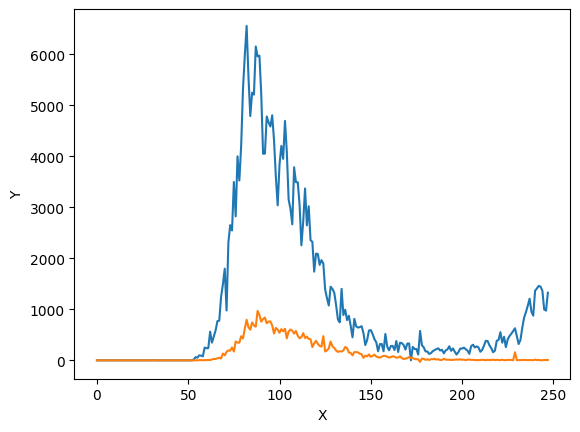

In [ ]:
df.new_cases.plot(kind='line',xlabel='X'),df.new_deaths.plot(kind='line',ylabel='Y')
# df.new_tests.plot()

<Axes: title={'center': 'Total cases'}, xlabel='X'>

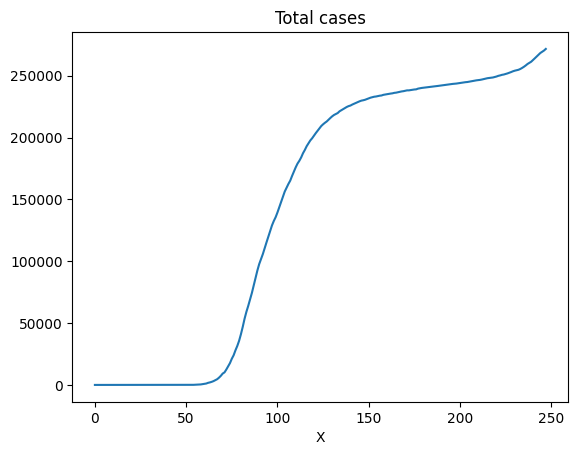

In [ ]:
df.total_cases.plot(kind='line',xlabel='X',title='Total cases')

In [ ]:
from os import initgroups
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
flower_df = sns.load_dataset('iris')
flower_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
sns.set_style('darkgrid')

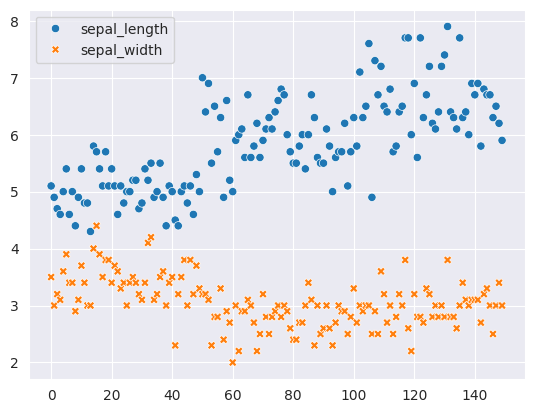

In [ ]:
sns.scatterplot(data = (flower_df.sepal_length,flower_df.sepal_width));

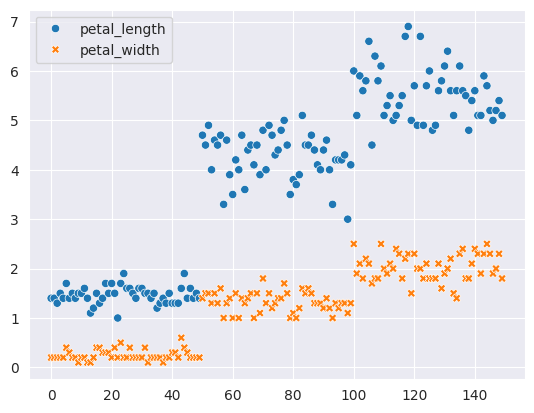

In [ ]:
sns.scatterplot(data = (flower_df.petal_length,flower_df.petal_width));